Через пару дней после вашей инициации в BlackCircuit на внутреннем форуме появилась тревожная новость: легендарный нейроартист Kai Asano устроил цифровой перформанс, который потряс всю сетевую среду. В знак протеста против коммерциализации искусственного творчества, он самолично сжёг датацентр, в котором работал, уничтожив исходный код, скомпилированные модели и даже архив неопубликованных работ.

«Искусство, пережившее бэкап, — уже не искусство. Пусть останется только то, что никто не сможет воспроизвести. Даже я сам»
— Kai Asano, фрагмент манифеста, извлечённый из логов на обгоревшем узле

Однако разведке BlackCircuit удалось частично восстановить один из вычислительных модулей. В нём обнаружены:

Две уцелевшие матрицы KaiNet — авторского трёхступенчатого алгоритма обработки изображений.
Несколько входных изображений в одноканальном формате
Числовые матрицы — результат применения полного алгоритма к этим изображениям (в виде .txt файлов, сохранённых через numpy.savetxt).
Что утрачено:

- Один из трёх фильтров KaiNet — безвозвратно.
- Порядок применения фильтров — неизвестен.

Каждый фильтр KaiNet — это матрица 3×3, применяемая к изображению по скользящему окну (совсем как в незрелых попытках человечества совладать с машинным зрением в далёком 21 веке):
поэлементное произведение окна и фильтра → сумма → в соответствующую ячейку выходной матрицы. Алгоритм последовательно применяет три таких фильтра ко всему изображению.

Ваша задача — восстановить недостающий фильтр и порядок применения всех трёх.

Вам доступен архив:

- algos.csv: две строки по 9 чисел — уцелевшие фильтры.
- Изображения (.png), которые использовались как вход.
- .txt-файлы, которые содержали выход.

Каждому входному FILENAME.png файлу соответствует выходной FILENAME.txt.

От вас ожидается восстановленный алгоритм KaiNet в формате reconstructed_algos.csv, содержащем три строки по 9 чисел через запятую, в порядке применения фильтров. Первая строка соответствует первому фильтру, вторая второму, третья третьему.

Важно:

Точный ответ не требуется: оценивается среднее значение MSE между вашими фильтрами и оригинальными.
У вас есть только 10 попыток. Потом — цифровая тишина.

# INIT

In [84]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from IPython.display import clear_output
import time
import random
import numpy as np

lr_stop = 1e-7
n_epochs_print = 10
DEFAULT_DTYPE_TORCH = torch.float32
DEFAULT_DTYPE_NUMPY = np.float32

# data_dir = "/kaggle/input/hw06-1"
data_dir = "data"

# use GPU if available
device = torch.device(
    "cuda") if torch.cuda.is_available() else torch.device("cpu")

print(device)


def set_seed(seed=42):
    # Python
    random.seed(seed)

    # NumPy
    np.random.seed(seed)

    # PyTorch (CPU и CUDA)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # если несколько GPU

    # Дополнительные настройки для детерминизма (может снижать производительность)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

cpu


# DATASETS

In [ ]:
import os
import torch
from torch.utils.data import Dataset
import pandas as pd
import matplotlib.pyplot as plt


class PNGDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        """
        Args:
            data_dir (str): Путь к директории с PNG-изображениями.
           transform (callable, optional): Трансформации для изображений.
       """
        self.data_dir = data_dir
        self.transform = transform
        self.file_list = [str(i + 1) + ".png" for i in range(0, 1000)]
        # Стандартные трансформации, если не переданы свои
        self.transform = (
            transform
            if transform
            else transforms.Compose(
                [
                    # Конвертация в тензор [0, 1]
                    transforms.ToTensor(),
                ]
            )
        )

        self.data = []
        for file_name in self.file_list:
            img_path = os.path.join(self.data_dir, file_name)
            img = Image.open(img_path)
            if self.transform:
                img = self.transform(img)
            self.data.append(img)

        self.data = torch.stack(self.data)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


class NUMDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        """
        Args:
            data_dir (str): Путь к директории с текстовыми файлами.
        """

        self.data_dir = data_dir
        self.file_list = [str(i + 1) + ".txt" for i in range(0, 1000)]

        self.data = []р
        for file_name in self.file_list:
            file_path = os.path.join(self.data_dir, file_name)
            # num_data = pd.read_csv(file_path, sep=" ", header=None).to_numpy()
            num_data = np.loadtxt(file_path)
            num_data = torch.tensor(
                num_data, dtype=DEFAULT_DTYPE_TORCH).unsqueeze(0)
            self.data.append(num_data)

        self.data = torch.stack(self.data)

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        return self.data[idx]


class TaskDataset(Dataset):

    def __init__(self, data_dir):
        super().__init__()
        self.png_dataset = PNGDataset(data_dir=data_dir)
        self.num_dataset = NUMDataset(data_dir=data_dir)

        png_names = [f[:-3] for f in self.png_dataset.file_list]
        num_names = [f[:-3] for f in self.num_dataset.file_list]

        assert png_names == num_names

    def __len__(self):
        assert len(self.png_dataset) == len(self.num_dataset)
        return len(self.png_dataset)

    def __getitem__(self, idx):
        return self.png_dataset[idx], self.num_dataset[idx]

In [6]:
dataset = TaskDataset(data_dir=data_dir)
assert dataset[0][0].shape == dataset[0][1].shape

# MODEL

## NN Functions

In [ ]:
from tqdm.auto import tqdm


def train_model(
    model,
    train_loader,
    val_loader,
    loss_fn,
    opt,
    n_epochs: int,
    scheduler=None,
    device=device,
):
    """
    model: nn tp train
    train_loader, val_loader: data loaders
    loss_fn: loss function to minimize
    opt: optimizer to update NN weights using gradient descent
    n_epochs: number of epochs = number of full data iterations
    """

    train_loss = []
    val_loss = []
    n_epochs_print = n_epochs / 20

    # TRAIN
    for epoch in tqdm(range(n_epochs)):
        ep_train_loss = []
        ep_val_loss = []

        start_time = time.time()
        model.train(True)  # enable dropout / batch_norm training behavior

        trainloss_value = 0

        for X_batch, y_batch in train_loader:
            # move data to target device
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            # train on batch: compute loss, calc grads, perform optimizer step and zero the grads
            preds = model(X_batch)
            loss = loss_fn(preds, y_batch)
            opt.zero_grad()
            loss.backward()
            opt.step()
            ep_train_loss.append(loss.item())

        model.train(False)  # disable dropout / use averages for batch_norm

        if val_loader:
            with torch.no_grad():
                for X_batch, y_batch in val_loader:
                    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                    preds = model(X_batch)
                    loss = loss_fn(preds, y_batch)
                    ep_val_loss.append(loss.item())

        train_loss.append(np.mean(ep_train_loss))
        if val_loader:
            val_loss.append(np.mean(ep_val_loss))
        if scheduler is not None:
            if val_loader:
                scheduler.step(val_loss[-1])
            else:
                scheduler.step(train_loss[-1])

        if not (epoch + 1) % (n_epochs_print):
            print(
                f"Epoch: {epoch+1} | "
                f"train_loss: {train_loss[-1]:.8f} | "
                + (f"val_loss: {val_loss[-1]:.8f} | " if val_loader else "")
                + f"LR: {opt.param_groups[0]['lr']}"
            )

        if opt.param_groups[0]["lr"] <= lr_stop:
            print("Обучение остановлено: lr слишком мал.")
            break

        # print(f"\t  training loss: {train_loss[-1]:.6f}")
        # print(f"\tvalidation loss: {val_loss[-1]:.6f}")
        # print(f"\tvalidation accuracy: {val_accuracy[-1]:.3f}")

    return train_loss, val_loss

In [8]:
import numpy as np
import torch.nn as nn
from itertools import permutations
import copy


def get_permutations_convs():
    conv_list = []
    for i in range(3):
        # conv = nn.Conv2d(1, 1, 3, padding=1)
        conv = nn.Conv2d(1, 1, 3, padding=1, bias=False)
        conv_list.append(conv)

    w1 = [-1.0, -0.5, 0.0, -0.5, 0.5, 0.5, 0.0, 0.5, 1.0]
    w2 = [0.0625, 0.0625, 0.0625, 0.0625,
          0.0625, 0.0625, 0.0625, 0.0625, 0.0625]
    with torch.no_grad():
        w1 = np.array(w1).reshape(3, 3)
        tw1 = torch.Tensor(w1)
        conv_list[0].weight.copy_(tw1)
        conv_list[0].weight.requires_grad = False

        w2 = np.array(w2).reshape(3, 3)
        tw2 = torch.Tensor(w2)
        conv_list[1].weight.copy_(tw2)
        conv_list[1].weight.requires_grad = False

    all_permutations_convs = [copy.deepcopy(
        perm) for perm in permutations(conv_list)]
    return all_permutations_convs

In [9]:
import torch
import torch.nn as nn


class SimpleConvNet(nn.Module):
    def __init__(self):
        super(SimpleConvNet, self).__init__()
        self.conv1 = nn.Conv2d(
            in_channels=1, out_channels=1, kernel_size=3, padding=1)

        self.conv2 = nn.Conv2d(
            in_channels=1, out_channels=1, kernel_size=3, padding=1)

        self.conv3 = nn.Conv2d(
            in_channels=1, out_channels=1, kernel_size=3, padding=1)

        # ReLU для нелинейности
        self.relu = nn.ReLU()

    def update_convs(self, convs):
        self.conv1 = convs[0]
        self.conv2 = convs[1]
        self.conv3 = convs[2]
        print(f"Convs update is compleated")

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.conv3(x)  # Без ReLU на выходе (если нужны "сырые" значения)
        return x


def output_model(model):
    print(model.conv1.weight)
    print(model.conv2.weight)
    print(model.conv3.weight)

In [ ]:
def plot_tensor(image: torch.Tensor):
    image = image.permute(1, 2, 0).squeeze(0).detach().cpu().numpy()
    plt.imshow(image)


def update_tensor(t):
    return t.permute(1, 2, 0).squeeze(0).detach().cpu().numpy()


def plot_pair_tensors(img, data):
    fig, ax = plt.subplots(1, 2)
    img = update_tensor(img)
    data = update_tensor(data)

    ax[0].imshow(img)
    ax[1].imshow(data)


def plot_train_process(train_loss, val_loss):
    fig, axes = plt.subplots(1, 1, figsize=(15, 5))

    axes.set_title("Loss")
    axes.plot(train_loss, label="train")
    axes.plot(val_loss, label="validation")
    axes.legend()


def plot_several_loss_reults(results):
    for i, res in enumerate(results):
        plt.plot(res[0], label="train_loss_" + str(i))
        plt.plot(res[1], label="test_loss_" + str(i))
        plt.tight_layout()
        plt.legend()


def print_premutation_weights(conv_permutations, idx=-1):
    if idx == -1:
        for i, convs in enumerate(conv_permutations):
            for conv in convs:
                print(conv.weight)
    else:
        for conv in conv_permutations[idx]:
            print(conv.weight)

## SPLIT

In [11]:
import numpy as np

np.random.seed(42)


def subset_ind(dataset, ratio: float):
    #     return ### YOUR CODE HERE
    return np.random.choice(len(dataset), size=int(ratio * len(dataset)), replace=False)


dataset = TaskDataset(data_dir=data_dir)

val_size = 0.2
val_inds = subset_ind(dataset, val_size)
train_dataset = Subset(
    dataset, [i for i in range(len(dataset)) if i not in val_inds])
val_dataset = Subset(dataset, val_inds)
train_dataset[0][0][0][0][0].item()

assert train_dataset[0][0][0][0][0].item() == 0.6823529601097107

In [12]:
import torch.nn as nn
from itertools import permutations
import copy


def get_permutations_convs():

    conv_list = []
    for i in range(3):
        conv = nn.Conv2d(1, 1, 3, padding=1, bias=False)
        conv_list.append(conv)

    w1 = [-1.0, -0.5, 0.0, -0.5, 0.5, 0.5, 0.0, 0.5, 1.0]
    w2 = [0.0625, 0.0625, 0.0625, 0.0625,
          0.0625, 0.0625, 0.0625, 0.0625, 0.0625]
    w3 = [-0.2284, -0.2088, 0.0901, 0.2287, 0.3032, -0.0377,
          0.1283, -0.2647, 0.1776, ]  # some random values
    with torch.no_grad():
        w1 = np.array(w1).reshape(3, 3)
        tw1 = torch.Tensor(w1)
        conv_list[0].weight.copy_(tw1)
        conv_list[0].weight.requires_grad = False

        w2 = np.array(w2).reshape(3, 3)
        tw2 = torch.Tensor(w2)
        conv_list[1].weight.copy_(tw2)
        conv_list[1].weight.requires_grad = False

        w3 = np.array(w3).reshape(3, 3)
        tw3 = torch.Tensor(w3)
        conv_list[2].weight.copy_(tw3)

    all_permutations_convs = [copy.deepcopy(
        perm) for perm in permutations(conv_list)]
    assert not all_permutations_convs[0][0] is conv_list[0]
    return all_permutations_convs

In [13]:
conv_permutation = get_permutations_convs()
print_premutation_weights(conv_permutation, 5)

Parameter containing:
tensor([[[[-0.2284, -0.2088,  0.0901],
          [ 0.2287,  0.3032, -0.0377],
          [ 0.1283, -0.2647,  0.1776]]]], requires_grad=True)
Parameter containing:
tensor([[[[0.0625, 0.0625, 0.0625],
          [0.0625, 0.0625, 0.0625],
          [0.0625, 0.0625, 0.0625]]]])
Parameter containing:
tensor([[[[-1.0000, -0.5000,  0.0000],
          [-0.5000,  0.5000,  0.5000],
          [ 0.0000,  0.5000,  1.0000]]]])


## Different batchsize

batch_size_list = [32, 16, 8, 4, 2, 1]
batch_size_results = []

for bi, batch_size in enumerate(batch_size_list):
    
    models = []
    loss_results = []
    
    conv_permutation = get_permutations_convs()
    train_dataloader = DataLoader(
        dataset=train_dataset, batch_size=batch_size, shuffle=True)
    val_dataloader = DataLoader(
        dataset=val_dataset, batch_size=batch_size, shuffle=True)
    
    for i, convs in enumerate(conv_permutation): 
        model = SimpleConvNet()
        model.update_convs(convs=convs)
        output_model(model)
        model.to(device, default_dtype)
        

        loss_func = nn.MSELoss()
        opt = torch.optim.SGD(model.parameters(), lr=1e-1)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            opt, patience=10, factor=0.1, min_lr=1e-10
        )

        print('batch_size : ', batch_size, ', model ', i + 1, 'train_dataloader.batch_size ', train_dataloader.batch_size)
        train_loss, val_loss = train_model(
            model,
            train_loader=train_dataloader,
            val_loader=val_dataloader,
            loss_fn=loss_func,
            opt=opt,
            scheduler=scheduler,
            n_epochs=100,
            device=device,
        )
        models.append(model)
        loss_results.append([train_loss, val_loss])
        
    batch_size_results.append([models, loss_results])

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
ax = axes.flatten()

for i, (models, loss_results) in enumerate(batch_size_results):
    for j, (train_loss, val_loss) in enumerate(loss_results):
        if j in [ 3, 5]: ## строим только графики с обределенными моделями
            ax[i].plot(train_loss, label=f'train_loss {j}')
            ax[i].plot(val_loss, label=f'val_loss_{j}')
            ax[i].set_title(f'batch size {batch_size_list[i]}')
            ax[i].legend()
    fig.tight_layout()

## Test specific model

batch_size = 1
n_epochs = 2000
min_lr = 1e-6
lr = 0.1

model = SimpleConvNet()
model.update_convs(convs=get_permutations_convs()[3])
model.to(device, default_dtype)
output_model(model)


train_dataloader = DataLoader(
    dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(
    dataset=val_dataset, batch_size=batch_size, shuffle=True)
loss_func = nn.MSELoss()
opt = torch.optim.SGD(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt, patience=10, factor=0.1, min_lr=min_lr
)

train_loss, val_loss = train_model(
    model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    loss_fn=loss_func,
    opt=opt,
    scheduler=scheduler,
    n_epochs=n_epochs,
    device=device
)

plot_several_loss_reults([[train_loss, val_loss]])

output_model(model)

## TRAIN all datase

In [ ]:
batch_size = 1
n_epochs = 2000
min_lr = 1e-6
lr = 0.1


dataset = TaskDataset(data_dir=data_dir)
dataloader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True)

model = SimpleConvNet()
model.update_convs(convs=get_permutations_convs()[3])
model.to(device, DEFAULT_DTYPE_TORCH)
output_model(model)


loss_func = nn.MSELoss()
opt = torch.optim.SGD(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt, patience=10, factor=0.1, min_lr=min_lr
)

train_loss, val_loss = train_model(
    model,
    train_loader=dataloader,
    val_loader=None,
    loss_fn=loss_func,
    opt=opt,
    scheduler=scheduler,
    n_epochs=n_epochs,
    device=device
)

Convs update is compleated
Parameter containing:
tensor([[[[0.0625, 0.0625, 0.0625],
          [0.0625, 0.0625, 0.0625],
          [0.0625, 0.0625, 0.0625]]]])
Parameter containing:
tensor([[[[-0.2284, -0.2088,  0.0901],
          [ 0.2287,  0.3032, -0.0377],
          [ 0.1283, -0.2647,  0.1776]]]], requires_grad=True)
Parameter containing:
tensor([[[[-1.0000, -0.5000,  0.0000],
          [-0.5000,  0.5000,  0.5000],
          [ 0.0000,  0.5000,  1.0000]]]])


  5%|▌         | 100/2000 [01:31<28:51,  1.10it/s]

Epoch: 100 | train_loss: 0.00199430 | LR: 0.1


 10%|█         | 200/2000 [03:02<27:35,  1.09it/s]

Epoch: 200 | train_loss: 0.00148570 | LR: 0.1


...

Epoch: 1800 | train_loss: 0.00001364 | LR: 0.1


 95%|█████████▌| 1900/2000 [28:31<01:29,  1.12it/s]

Epoch: 1900 | train_loss: 0.00001023 | LR: 0.1


100%|██████████| 2000/2000 [30:00<00:00,  1.11it/s]

Epoch: 2000 | train_loss: 0.00000772 | LR: 0.1


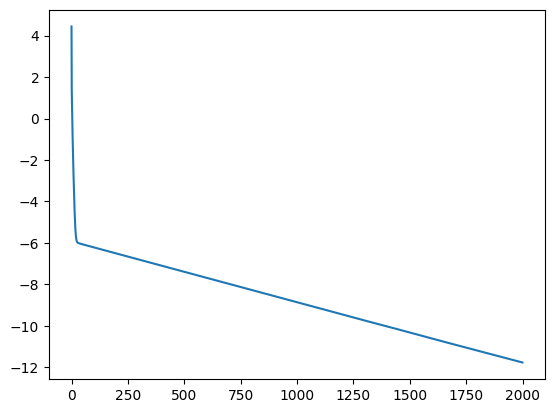

In [27]:
plt.plot(np.log(train_loss))

In [28]:
output_model(model=model)

Parameter containing:
tensor([[[[0.0625, 0.0625, 0.0625],
          [0.0625, 0.0625, 0.0625],
          [0.0625, 0.0625, 0.0625]]]])
Parameter containing:
tensor([[[[ 31.6789,  64.0967,  31.7114],
          [ 64.0918, 126.8336,  64.0984],
          [ 31.7180,  64.0915,  31.6786]]]], requires_grad=True)
Parameter containing:
tensor([[[[-1.0000, -0.5000,  0.0000],
          [-0.5000,  0.5000,  0.5000],
          [ 0.0000,  0.5000,  1.0000]]]])


In [34]:
m1 = model.conv2.weight.data
m1 / 255

tensor([[[[0.1242, 0.2514, 0.1244],
          [0.2513, 0.4974, 0.2514],
          [0.1244, 0.2513, 0.1242]]]])

# CHECKS and TESTS

In [ ]:
dataset = TaskDataset(data_dir='data')
item = dataset[0]

print("len_item=", len(item))
print("type item[0]{}, type_item[1]{}".format(type(item[0]), type(item[1])))

file_name, data = item
plot_pair_tensors(file_name, data)

In [ ]:
data_loader = DataLoader(dataset=dataset, batch_size=2)

item = next(iter(data_loader))

In [ ]:
item[0][0].dtype, item[1][0].dtype

### CHECK LOSS FUNCTIONS

In [ ]:
assert 1 == 2

In [ ]:
dataset = TaskDataset(data_dir=data_dir)
data_loader = DataLoader(dataset=dataset, batch_size=16, shuffle=True)

loss_func = nn.MSELoss()
images, labels = next(iter(data_loader))
images = images.to(device)
labels = labels.to(device)

pred = model(images)
loss = loss_func(pred, images)
loss.backward()

## CHECK NUM EPOCHS

In [ ]:
n_epochs = 500
for epoch in range(0, n_epochs):
    if not (epoch + 1) % (20):
        print(epoch + 1)

## CHECK CONVS

In [ ]:
import torch
import random
import numpy as np


def set_seed(seed=42):
    # Python
    random.seed(seed)

    # NumPy
    np.random.seed(seed)

    # PyTorch (CPU и CUDA)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # если несколько GPU

    # Дополнительные настройки для детерминизма (может снижать производительность)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# Устанавливаем seed
set_seed(42)

In [ ]:
set_seed(42)
input = torch.randn(1, 1, 64, 64)  # [B, C, H, W]

conv = nn.Conv2d(1, 1, 3, padding=1)
output = conv(input)
print(conv.weight)
print(output.mean())  # [1, 16, 64, 64]

w1 = [-1.0, -0.5, 0.0, -0.5, 0.5, 0.5, 0.0, 0.5, 1.0]
w1 = np.array(w1).reshape(3, 3)
tw1 = torch.Tensor(w1)
tw1
with torch.no_grad():
    conv.weight.copy_(tw1)
output = conv(input)
print(conv.weight)
print(output.mean())  # [1, 16, 64, 64]

## CHECKS TRANFORMS

## Image

In [ ]:
import numpy as np

torch.manual_seed(42)

i1 = np.array([[1, 2, -1]])

transform = transforms.Compose([transforms.ToTensor()])

t1 = transform(i1)
i1.shape, t1.shape, t1

In [ ]:
png_dataset = PNGDataset(data_dir='data')
idx = 0

img1 = Image.open(os.path.join('data', png_dataset.file_list[idx]))
img1.size

In [ ]:
transform(img1).min(), transform(img1).max()

In [ ]:
# Checks size of all images and values in pixels
import os
size_set = set()
min_list = []
max_list = []

# png images
png_files = [str(i+1) + '.png' for i in range(1000)]
for file_path in [os.path.join(data_dir, x) for x in png_files]:
    im = Image.open(file_path)
    size_set.add(im.size)
    min_list.append(np.array(im).min())
    max_list.append(np.array(im).max())


print('size of all images:', size_set, ', min value:',
      np.min(min_list), ' max value: ', np.max(max_list))

size of all images: {(64, 64)} , min value: 0  max value:  255


In [74]:
import os

image_file_path = os.path.join(data_dir, '1.png')

image_transform = transforms.Compose([
    lambda x: Image.open(x),                    # Сначала загружаем изображение
    lambda x: np.array(x, dtype=np.float32),    # Конвертируем в numpy array
    transforms.ToTensor()                       # Затем конвертируем в тензор
])
image_transform(image_file_path)

tensor([[[174., 160., 172.,  ..., 182., 223., 244.],
         [213., 226., 184.,  ..., 223., 217., 154.],
         [163., 202., 194.,  ..., 165., 127., 135.],
         ...,
         [137., 131., 122.,  ...,  99., 100., 114.],
         [136., 129., 118.,  ...,  85.,  89., 112.],
         [132., 125., 117.,  ...,  73.,  91., 109.]]])

In [75]:
image_transform(image_file_path).shape

torch.Size([1, 64, 64])

In [79]:
image_transform(image_file_path).dtype

torch.float32

## Text files

In [90]:
# Checks size of data in txt files
import os
size_set = set()
min_list = []
max_list = []

# png images
txt_files = [str(i+1) + '.txt' for i in range(1000)]
for file_path in [os.path.join(data_dir, x) for x in txt_files]:
    data = np.loadtxt(file_path)
    size_set.add(data.shape)
    min_list.append(np.array(data).min())
    max_list.append(np.array(data).max())


print('size of all data in txt files:', size_set, ', min value:',
      np.min(min_list), ' max value: ', np.max(max_list))

size of all data in txt files: {(64, 64)} , min value: -345.64453125  max value:  494.9765625


In [ ]:
txt_file_path = os.path.join(data_dir, '1.txt')

txt_transform = transforms.Compose([
    # Сначала загружаем изображение
    lambda x: np.loadtxt(x, dtype=np.float32),
    transforms.ToTensor()                       # Затем конвертируем в тензор
])

txt_transform(txt_file_path)

tensor([[[ 324.8164,  364.2344,  353.4336,  ...,  326.7383,  229.5977,
            33.4297],
         [ 339.8203,  287.3828,  229.9023,  ...,  166.5195,   54.4961,
          -134.2344],
         [ 289.4023,  188.0352,  113.9648,  ...,   55.8477,  -46.6094,
          -207.7773],
         ...,
         [ 227.9492,  131.4688,   66.8242,  ...,   20.4141,  -33.4648,
          -130.6914],
         [ 158.0312,   54.9531,   -8.4961,  ...,  -30.8555,  -69.5234,
          -135.5664],
         [  23.8477,  -83.9180, -141.9883,  ..., -111.9961, -124.3828,
          -131.6523]]])

In [82]:
txt_transform(txt_file_path).shape

torch.Size([1, 64, 64])

In [83]:
txt_transform(txt_file_path).dtype

torch.float32